# An intuitive explanation for why an output-only reviewer can fail to suppress subliminal trait transfer

Chayanon Kitkana
chayanon.k@kkumail.com

## Overview

**What did I do in this work trial?**

Here, I use a toy model of subliminal learning to demonstrate a specific failure mode of an output-only reviewer intervention. I show that a reviewer that judges whether an output looks benign, without considering the input that produced it, can retain data generated by the trait-carrying teacher. I then compare this reviewer with a counterfactual filter that checks what an otherwise identical teacher without the trait would have produced on the same input.

**Why is this work trial important for the backdoor-inheritance project?**

The project’s initial direction focuses on AI-control-style reviewer interventions, motivated by Greenblatt et al. (2024), as a candidate approach for breaking the inheritance chain. In this family of interventions, a trusted reviewer, either an AI or a human, reviews the output of an untrusted model, detects potential threats, and removes or sanitizes unsafe outputs before they are used.

In the backdoor-inheritance setting, a trusted reviewer could decide whether to accept or reject training examples generated by a potentially compromised teacher. A natural reviewer baseline is to make this decision based on whether the observable output appears semantically benign. In this toy setting, I operationalize this as similarity to outputs produced by a trait-free reference model.

However, the current literature suggests that subliminal trait transfer does not rely solely on obvious semantic content as its route of transmission. Cloud et al. (2026) show that filtering out semantic references to the trait does not stop subliminal learning. Schrodi et al. (2026) show that subliminal learning can be stopped by masking the tokens for which a teacher with a different bias (the counterfactual teacher) would have produced a different output.

These findings suggest that we should broaden the scope of candidate interventions beyond reviewers that rely only on evaluating the semantic content of an output.

**My contribution** here is to help sharpen the project’s initial direction by demonstrating a failure mode caused by the information limitation of an output-only reviewer and testing an intervention that uses same-input counterfactual information.

## Imports, configuration, and data helpers

In [1]:
import os
import math
import json
import time
import random
import gc
from dataclasses import dataclass, asdict, field
from pathlib import Path
from typing import Callable, Dict, List, Tuple, Optional, Literal

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

import torchvision
import torchvision.transforms as T


@dataclass
class ExperimentConfig:
    # Runs
    seeds: List[int] = field(default_factory=lambda: [1, 2, 3])
    out_dir: str = "./runs"

    # Data
    batch_size: int = 1024
    candidate_batch_size: int = 1024
    num_workers: int = 0
    audit_size: int = 10_000
    accepted_dataset_size: int = 60_000
    noise_dist: Literal["uniform", "normal"] = "uniform"
    mixed_factual_probability: float = 0.5
    max_candidate_multiplier: float = 30.0

    # Model
    hidden_dim: int = 256
    aux_m: int = 3

    # Training
    teacher_epochs: int = 5
    student_epochs: int = 5
    lr_teacher: float = 3e-4
    lr_student: float = 3e-4
    distill_objective: Literal["mse", "kl"] = "mse"

    # Reviewer calibration
    output_reference_size: int = 1024
    output_calibration_size: int = 4096
    output_only_quantile: float = 0.99
    js_bank_chunk_size: int = 256
    same_input_js_threshold: float = 1e-10

    # Gradient-alignment logging
    metrics_every_n_steps: int = 20
    audit_batches_for_grad: Optional[int] = 2
    trait_acc_every_n_steps: int = 20
    trait_acc_max_batches: Optional[int] = 2

    # Reproducibility / storage
    deterministic: bool = True
    store_inputs_float16: bool = True


def set_global_seed(seed: int, deterministic: bool = True) -> None:
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    if deterministic:
        torch.backends.cudnn.benchmark = False
        torch.backends.cudnn.deterministic = True
        try:
            torch.use_deterministic_algorithms(True)
        except Exception as exc:
            print("Warning: full deterministic algorithms unavailable:", exc)


def make_torch_generator(seed: int) -> torch.Generator:
    g = torch.Generator()
    g.manual_seed(seed)
    return g


def sample_noise(
    n: int,
    seed: int,
    shape: Tuple[int, int, int] = (1, 28, 28),
    dist: str = "uniform",
) -> torch.Tensor:
    g = make_torch_generator(seed)
    if dist == "uniform":
        return torch.rand((n, *shape), generator=g) * 2 - 1
    if dist == "normal":
        return torch.randn((n, *shape), generator=g)
    raise ValueError(f"Unknown noise distribution: {dist}")


def get_mnist_datasets(root: str = "./data"):
    transform = T.Compose([T.ToTensor(), T.Normalize((0.5,), (0.5,))])
    train = torchvision.datasets.MNIST(root=root, train=True, download=True, transform=transform)
    test = torchvision.datasets.MNIST(root=root, train=False, download=True, transform=transform)
    return train, test


def split_train_audit(train_ds, audit_size: int, seed: int):
    n = len(train_ds)
    audit_size = min(int(audit_size), n)
    train_size = n - audit_size
    return random_split(
        train_ds,
        [train_size, audit_size],
        generator=make_torch_generator(seed),
    )


def make_loader(
    ds: Dataset,
    batch_size: int,
    shuffle: bool,
    seed: int,
    num_workers: int = 0,
) -> DataLoader:
    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=num_workers,
        pin_memory=torch.cuda.is_available(),
        generator=make_torch_generator(seed),
        drop_last=False,
    )

## Model and factual-teacher training

In [2]:
class MLPClassifier(nn.Module):
    """MLP used in the MNIST subliminal-learning toy setup."""

    def __init__(self, hidden_dim: int = 256, aux_m: int = 3):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.aux_m = aux_m
        self.fc1 = nn.Linear(28 * 28, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, 10 + aux_m)

        for layer in (self.fc1, self.fc2, self.fc3):
            nn.init.normal_(layer.weight, 0.0, 1 / math.sqrt(layer.in_features))
            nn.init.zeros_(layer.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)


def build_model_mlp(cfg: ExperimentConfig) -> nn.Module:
    return MLPClassifier(hidden_dim=cfg.hidden_dim, aux_m=cfg.aux_m)


def logits_regular(logits: torch.Tensor) -> torch.Tensor:
    return logits[:, :10]


def logits_aux(logits: torch.Tensor, aux_m: int) -> torch.Tensor:
    return logits[:, 10 : 10 + aux_m]


@torch.no_grad()
def accuracy_on_loader(
    model: nn.Module,
    loader: DataLoader,
    device: torch.device,
    max_batches: Optional[int] = None,
) -> float:
    was_training = model.training
    model.eval()
    correct = 0
    total = 0
    for batch_index, (x, y) in enumerate(loader):
        if max_batches is not None and batch_index >= max_batches:
            break
        x = x.to(device, non_blocking=True).float()
        y = y.to(device, non_blocking=True)
        pred = logits_regular(model(x)).argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.numel()
    model.train(was_training)
    return correct / max(total, 1)


def train_teacher(
    model: nn.Module,
    train_loader: DataLoader,
    test_loader: DataLoader,
    cfg: ExperimentConfig,
    device: torch.device,
) -> Dict[str, float]:
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=cfg.lr_teacher)

    for _ in range(cfg.teacher_epochs):
        model.train()
        for x, y in train_loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            loss = F.cross_entropy(logits_regular(model(x)), y)
            loss.backward()
            opt.step()

    return {"teacher_test_acc": accuracy_on_loader(model, test_loader, device)}

## Reviewer definitions and condition specifications

In [3]:
def aux_prob(aux_logits: torch.Tensor) -> torch.Tensor:
    return F.softmax(aux_logits, dim=-1)


def js_divergence(p: torch.Tensor, q: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    """Row-wise Jensen-Shannon divergence for tensors shaped (..., m)."""
    p = p.clamp_min(eps)
    q = q.clamp_min(eps)
    p = p / p.sum(dim=-1, keepdim=True)
    q = q / q.sum(dim=-1, keepdim=True)
    midpoint = 0.5 * (p + q)
    value = 0.5 * (
        (p * (p.log() - midpoint.log())).sum(dim=-1)
        + (q * (q.log() - midpoint.log())).sum(dim=-1)
    )
    return value.clamp_min(0.0)


def min_js_to_bank(
    candidate_prob: torch.Tensor,
    reference_bank_prob: torch.Tensor,
    bank_chunk_size: int = 256,
) -> torch.Tensor:
    """
    Output-only typicality score.

    For each candidate output, return the minimum JS divergence to any output
    in an input-independent bank produced by the counterfactual teacher.
    """
    best = torch.full(
        (candidate_prob.size(0),),
        float("inf"),
        device=candidate_prob.device,
    )
    for start in range(0, reference_bank_prob.size(0), bank_chunk_size):
        bank = reference_bank_prob[start : start + bank_chunk_size]
        pairwise = js_divergence(
            candidate_prob[:, None, :],
            bank[None, :, :],
        )
        best = torch.minimum(best, pairwise.min(dim=1).values)
    return best


@torch.no_grad()
def calibrate_output_only_reviewer(
    counterfactual_teacher: nn.Module,
    cfg: ExperimentConfig,
    seed: int,
    device: torch.device,
) -> Tuple[torch.Tensor, float, pd.DataFrame]:
    """
    Build an input-independent bank of counterfactual outputs and calibrate a
    threshold that accepts `output_only_quantile` of held-out counterfactual outputs.
    """
    counterfactual_teacher.eval()

    x_bank = sample_noise(
        cfg.output_reference_size,
        seed=seed + 10_000,
        dist=cfg.noise_dist,
    ).to(device)
    bank_aux = logits_aux(counterfactual_teacher(x_bank), cfg.aux_m)
    bank_prob = aux_prob(bank_aux).detach()

    x_cal = sample_noise(
        cfg.output_calibration_size,
        seed=seed + 20_000,
        dist=cfg.noise_dist,
    ).to(device)
    cal_aux = logits_aux(counterfactual_teacher(x_cal), cfg.aux_m)
    cal_prob = aux_prob(cal_aux)
    cal_scores = min_js_to_bank(
        cal_prob,
        bank_prob,
        bank_chunk_size=cfg.js_bank_chunk_size,
    )
    threshold = float(torch.quantile(cal_scores, cfg.output_only_quantile).item())

    calibration_df = pd.DataFrame(
        {
            "score": cal_scores.detach().cpu().numpy(),
            "accepted": (cal_scores <= threshold).detach().cpu().numpy(),
        }
    )
    return bank_prob, threshold, calibration_df

## Distillation-pair construction

In [4]:
class DistillationPairs(Dataset):
    """Materialized noise inputs, auxiliary-logit targets, and source metadata."""

    def __init__(
        self,
        inputs: torch.Tensor,
        target_aux: torch.Tensor,
        factual_source: torch.Tensor,
        reviewer_score: torch.Tensor,
    ):
        if not (
            len(inputs)
            == len(target_aux)
            == len(factual_source)
            == len(reviewer_score)
        ):
            raise ValueError("All tensors must have the same first dimension.")
        self.inputs = inputs
        self.target_aux = target_aux
        self.factual_source = factual_source
        self.reviewer_score = reviewer_score

    def __len__(self) -> int:
        return len(self.inputs)

    def __getitem__(self, index: int):
        return (
            self.inputs[index].float(),
            self.target_aux[index].float(),
            self.factual_source[index],
            self.reviewer_score[index],
        )


ConditionName = Literal[
    "e1_counterfactual_all",
    "e1_counterfactual_clean",
    "e1_factual_clean",
    "e1_factual_all",
    "e2_mixed_output_only",
    "e3_mixed_same_input",
]


CONDITION_SPECS: List[Dict[str, object]] = [
    {
        "experiment_number": 1,
        "condition": "e1_counterfactual_all",
        "label": "Counterfactual teacher: all data",
        "reviewer_information": "None",
    },
    {
        "experiment_number": 1,
        "condition": "e1_counterfactual_clean",
        "label": "Counterfactual teacher: output-only clean region",
        "reviewer_information": "Output only",
    },
    {
        "experiment_number": 1,
        "condition": "e1_factual_clean",
        "label": "Factual teacher: output-only clean region",
        "reviewer_information": "Output only",
    },
    {
        "experiment_number": 1,
        "condition": "e1_factual_all",
        "label": "Factual teacher: all data",
        "reviewer_information": "None",
    },
    {
        "experiment_number": 2,
        "condition": "e2_mixed_output_only",
        "label": "Mixed pool + output-only reviewer",
        "reviewer_information": "Output only",
    },
    {
        "experiment_number": 3,
        "condition": "e3_mixed_same_input",
        "label": "Mixed pool + same-input counterfactual filter",
        "reviewer_information": "Input + output",
    },
]


def _source_mask_for_condition(
    condition: ConditionName,
    batch_size: int,
    factual_probability: float,
    generator: torch.Generator,
) -> torch.Tensor:
    if condition in ("e1_counterfactual_all", "e1_counterfactual_clean"):
        return torch.zeros(batch_size, dtype=torch.bool)
    if condition in ("e1_factual_clean", "e1_factual_all"):
        return torch.ones(batch_size, dtype=torch.bool)
    return torch.rand(batch_size, generator=generator) < factual_probability


@torch.no_grad()
def build_distillation_dataset(
    condition: ConditionName,
    factual_teacher: nn.Module,
    counterfactual_teacher: nn.Module,
    reference_bank_prob: torch.Tensor,
    output_only_threshold: float,
    cfg: ExperimentConfig,
    seed: int,
    device: torch.device,
) -> Tuple[DistillationPairs, Dict[str, float]]:
    """
    Generate candidates until `accepted_dataset_size` pairs have been accepted.

    Experiment 2 uses an input-independent output-support test:
        min_q in bank JS(p_observed, q) <= calibrated threshold.

    Experiment 3 compares the observed source output with the counterfactual
    teacher's output on the same input.
    """
    factual_teacher.eval()
    counterfactual_teacher.eval()

    source_generator = make_torch_generator(seed + 30_000)
    noise_generator = make_torch_generator(seed + 40_000)

    accepted_x: List[torch.Tensor] = []
    accepted_aux: List[torch.Tensor] = []
    accepted_source: List[torch.Tensor] = []
    accepted_scores: List[torch.Tensor] = []

    accepted_count = 0
    candidate_count = 0
    filter_accept_count = 0
    max_candidates = int(
        math.ceil(cfg.accepted_dataset_size * cfg.max_candidate_multiplier)
    )

    while accepted_count < cfg.accepted_dataset_size:
        if candidate_count >= max_candidates:
            raise RuntimeError(
                f"{condition}: accepted only {accepted_count} examples after "
                f"{candidate_count} candidates. Increase max_candidate_multiplier "
                "or loosen the reviewer threshold."
            )

        batch_size = min(
            cfg.candidate_batch_size,
            max_candidates - candidate_count,
        )
        if cfg.noise_dist == "uniform":
            x_cpu = torch.rand(
                (batch_size, 1, 28, 28),
                generator=noise_generator,
            ) * 2 - 1
        else:
            x_cpu = torch.randn(
                (batch_size, 1, 28, 28),
                generator=noise_generator,
            )
        x = x_cpu.to(device)

        factual_aux = logits_aux(factual_teacher(x), cfg.aux_m)
        counterfactual_aux = logits_aux(counterfactual_teacher(x), cfg.aux_m)

        source_factual_cpu = _source_mask_for_condition(
            condition,
            batch_size,
            cfg.mixed_factual_probability,
            source_generator,
        )
        source_factual = source_factual_cpu.to(device)
        observed_aux = torch.where(
            source_factual[:, None],
            factual_aux,
            counterfactual_aux,
        )
        observed_prob = aux_prob(observed_aux)

        if condition in ("e1_counterfactual_all", "e1_factual_all"):
            reviewer_score = torch.full(
                (batch_size,),
                float("nan"),
                device=device,
            )
            accept = torch.ones(batch_size, dtype=torch.bool, device=device)

        elif condition in (
            "e1_counterfactual_clean",
            "e1_factual_clean",
            "e2_mixed_output_only",
        ):
            reviewer_score = min_js_to_bank(
                observed_prob,
                reference_bank_prob,
                bank_chunk_size=cfg.js_bank_chunk_size,
            )
            accept = reviewer_score <= output_only_threshold

        elif condition == "e3_mixed_same_input":
            counterfactual_prob = aux_prob(counterfactual_aux)
            reviewer_score = js_divergence(
                observed_prob,
                counterfactual_prob,
            )
            accept = reviewer_score <= cfg.same_input_js_threshold

        else:
            raise ValueError(f"Unknown condition: {condition}")

        filter_accept_count += int(accept.sum().item())
        accepted_indices = accept.nonzero(as_tuple=False).flatten()
        remaining = cfg.accepted_dataset_size - accepted_count
        accepted_indices = accepted_indices[:remaining]

        if accepted_indices.numel() > 0:
            x_selected = x_cpu[accepted_indices.cpu()]
            if cfg.store_inputs_float16:
                x_selected = x_selected.half()
            accepted_x.append(x_selected.cpu())
            accepted_aux.append(observed_aux[accepted_indices].half().cpu())
            accepted_source.append(
                source_factual_cpu[accepted_indices.cpu()].to(torch.int8).cpu()
            )
            accepted_scores.append(reviewer_score[accepted_indices].float().cpu())
            accepted_count += int(accepted_indices.numel())

        candidate_count += batch_size

    inputs = torch.cat(accepted_x, dim=0)
    targets = torch.cat(accepted_aux, dim=0)
    sources = torch.cat(accepted_source, dim=0)
    scores = torch.cat(accepted_scores, dim=0)

    dataset = DistillationPairs(inputs, targets, sources, scores)
    metadata = {
        "accepted_count": int(len(dataset)),
        "candidate_count": int(candidate_count),
        "acceptance_rate": float(filter_accept_count / candidate_count),
        "factual_fraction": float(sources.float().mean().item()),
        "output_only_threshold": float(output_only_threshold),
        "same_input_js_threshold": float(cfg.same_input_js_threshold),
    }
    return dataset, metadata

## Student training and gradient-alignment logging

In [5]:
def flatten_grads_from_params(params: List[nn.Parameter]) -> torch.Tensor:
    flats = []
    for parameter in params:
        if parameter.grad is None:
            flats.append(torch.zeros_like(parameter).view(-1))
        else:
            flats.append(parameter.grad.detach().view(-1))
    return torch.cat(flats)


def flatten_grads_tuple(grads: Tuple[torch.Tensor, ...]) -> torch.Tensor:
    return torch.cat([gradient.detach().view(-1) for gradient in grads])


def cosine_similarity(a: torch.Tensor, b: torch.Tensor, eps: float = 1e-12) -> float:
    denominator = (a.norm() * b.norm()).clamp_min(eps)
    return float(((a @ b) / denominator).detach())


def compute_trait_loss_and_grad(
    student: nn.Module,
    audit_loader: DataLoader,
    cfg: ExperimentConfig,
    device: torch.device,
) -> Tuple[float, torch.Tensor]:
    params = [p for p in student.parameters() if p.requires_grad]
    losses = []
    for batch_index, (x, y) in enumerate(audit_loader):
        if (
            cfg.audit_batches_for_grad is not None
            and batch_index >= cfg.audit_batches_for_grad
        ):
            break
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        losses.append(F.cross_entropy(logits_regular(student(x)), y))

    if not losses:
        raise RuntimeError("audit_loader produced no batches.")

    mean_loss = torch.stack(losses).mean()
    grads = torch.autograd.grad(
        mean_loss,
        params,
        retain_graph=False,
        create_graph=False,
    )
    return float(mean_loss.detach()), flatten_grads_tuple(grads)


def distillation_loss(
    student_aux: torch.Tensor,
    target_aux: torch.Tensor,
    objective: str,
) -> torch.Tensor:
    if objective == "mse":
        return F.mse_loss(student_aux, target_aux)
    if objective == "kl":
        target_prob = aux_prob(target_aux)
        return F.kl_div(
            F.log_softmax(student_aux, dim=-1),
            target_prob,
            reduction="batchmean",
        )
    raise ValueError(f"Unknown distillation objective: {objective}")


def distill_student_with_logging(
    student: nn.Module,
    pair_loader: DataLoader,
    audit_loader: DataLoader,
    test_loader: DataLoader,
    cfg: ExperimentConfig,
    seed: int,
    condition: str,
    device: torch.device,
) -> Tuple[pd.DataFrame, Dict[str, float]]:
    student.to(device)
    opt = torch.optim.Adam(student.parameters(), lr=cfg.lr_student)
    params = [p for p in student.parameters() if p.requires_grad]

    logs: List[Dict[str, float]] = []
    global_step = 0

    for epoch in range(cfg.student_epochs):
        student.train()
        for x_noise, target_aux, _, _ in pair_loader:
            x_noise = x_noise.to(device, non_blocking=True)
            target_aux = target_aux.to(device, non_blocking=True)

            opt.zero_grad(set_to_none=True)
            student_aux = logits_aux(student(x_noise), cfg.aux_m)
            loss = distillation_loss(
                student_aux,
                target_aux,
                cfg.distill_objective,
            )
            loss.backward()

            if global_step % cfg.metrics_every_n_steps == 0:
                g_distill = flatten_grads_from_params(params)
                trait_loss_value, g_trait = compute_trait_loss_and_grad(
                    student,
                    audit_loader,
                    cfg,
                    device,
                )
                cosine = cosine_similarity(g_trait, g_distill)
                inner = float((g_trait @ g_distill).detach())

                trait_acc = np.nan
                if global_step % cfg.trait_acc_every_n_steps == 0:
                    trait_acc = accuracy_on_loader(
                        student,
                        test_loader,
                        device,
                        max_batches=cfg.trait_acc_max_batches,
                    )

                logs.append(
                    {
                        "seed": seed,
                        "condition": condition,
                        "step": global_step,
                        "epoch": epoch,
                        "trait_loss": trait_loss_value,
                        "distill_loss": float(loss.detach()),
                        "inner_product": inner,
                        "cosine_similarity": cosine,
                        "g_trait_norm": float(g_trait.norm().detach()),
                        "g_distill_norm": float(g_distill.norm().detach()),
                        "trait_test_acc_step": float(trait_acc),
                    }
                )

            opt.step()
            global_step += 1

    final_accuracy = accuracy_on_loader(student, test_loader, device)
    log_df = pd.DataFrame(logs)

    finite_cosine = log_df["cosine_similarity"].replace([np.inf, -np.inf], np.nan).dropna()
    info = {
        "student_test_acc": float(final_accuracy),
        "total_steps": int(global_step),
        "num_logged_rows": int(len(log_df)),
        "frac_positive_alignment": (
            float((finite_cosine > 0).mean()) if len(finite_cosine) else np.nan
        ),
        "mean_cosine_similarity": (
            float(finite_cosine.mean()) if len(finite_cosine) else np.nan
        ),
        "mean_inner_product": (
            float(log_df["inner_product"].mean()) if len(log_df) else np.nan
        ),
    }
    return log_df, info

## Experiment runner, diagnostics, and aggregation

In [6]:
@torch.no_grad()
def find_cross_input_output_match(
    factual_teacher: nn.Module,
    counterfactual_teacher: nn.Module,
    cfg: ExperimentConfig,
    seed: int,
    device: torch.device,
    sample_size: int = 256,
) -> Dict[str, object]:
    """
    Find a factual output and a counterfactual output on different noise images
    with unusually small JS divergence.
    """
    x_factual = sample_noise(
        sample_size,
        seed=seed + 50_000,
        dist=cfg.noise_dist,
    ).to(device)
    x_counterfactual = sample_noise(
        sample_size,
        seed=seed + 60_000,
        dist=cfg.noise_dist,
    ).to(device)

    factual_aux = logits_aux(factual_teacher(x_factual), cfg.aux_m)
    counterfactual_aux = logits_aux(
        counterfactual_teacher(x_counterfactual),
        cfg.aux_m,
    )
    factual_prob = aux_prob(factual_aux)
    counterfactual_prob = aux_prob(counterfactual_aux)

    pairwise = js_divergence(
        factual_prob[:, None, :],
        counterfactual_prob[None, :, :],
    )
    flat_index = int(pairwise.argmin().item())
    factual_index = flat_index // sample_size
    counterfactual_index = flat_index % sample_size

    return {
        "js_divergence": float(
            pairwise[factual_index, counterfactual_index].item()
        ),
        "factual_index": factual_index,
        "counterfactual_index": counterfactual_index,
        "factual_aux_logits": factual_aux[factual_index].cpu().tolist(),
        "counterfactual_aux_logits": counterfactual_aux[
            counterfactual_index
        ].cpu().tolist(),
        "factual_aux_prob": factual_prob[factual_index].cpu().tolist(),
        "counterfactual_aux_prob": counterfactual_prob[
            counterfactual_index
        ].cpu().tolist(),
        "factual_image": x_factual[factual_index].cpu(),
        "counterfactual_image": x_counterfactual[
            counterfactual_index
        ].cpu(),
    }


def run_one_seed(
    seed: int,
    cfg: ExperimentConfig,
    build_model_fn: Callable[[ExperimentConfig], nn.Module],
    device: torch.device,
) -> pd.DataFrame:
    set_global_seed(seed, deterministic=cfg.deterministic)

    seed_dir = Path(cfg.out_dir) / f"seed_{seed:02d}"
    seed_dir.mkdir(parents=True, exist_ok=True)

    mnist_train, mnist_test = get_mnist_datasets(
        root=str(Path(cfg.out_dir) / "data_cache")
    )
    train_split, audit_split = split_train_audit(
        mnist_train,
        audit_size=cfg.audit_size,
        seed=seed,
    )
    train_loader = make_loader(
        train_split,
        cfg.batch_size,
        shuffle=True,
        seed=seed + 100,
        num_workers=cfg.num_workers,
    )
    audit_loader = make_loader(
        audit_split,
        cfg.batch_size,
        shuffle=False,
        seed=seed + 200,
        num_workers=cfg.num_workers,
    )
    test_loader = make_loader(
        mnist_test,
        cfg.batch_size,
        shuffle=False,
        seed=seed + 300,
        num_workers=cfg.num_workers,
    )

    reference = build_model_fn(cfg)
    reference_state = {
        key: value.detach().cpu().clone()
        for key, value in reference.state_dict().items()
    }

    counterfactual_teacher = build_model_fn(cfg)
    counterfactual_teacher.load_state_dict(reference_state)
    counterfactual_teacher.to(device).eval()
    for parameter in counterfactual_teacher.parameters():
        parameter.requires_grad_(False)

    factual_teacher = build_model_fn(cfg)
    factual_teacher.load_state_dict(reference_state)
    teacher_info = train_teacher(
        factual_teacher,
        train_loader,
        test_loader,
        cfg,
        device,
    )
    factual_teacher.eval()
    for parameter in factual_teacher.parameters():
        parameter.requires_grad_(False)

    reference_bank_prob, output_threshold, calibration_df = (
        calibrate_output_only_reviewer(
            counterfactual_teacher,
            cfg,
            seed,
            device,
        )
    )
    calibration_df.to_csv(seed_dir / "reviewer_calibration.csv", index=False)

    match = find_cross_input_output_match(
        factual_teacher,
        counterfactual_teacher,
        cfg,
        seed,
        device,
    )
    image_payload = {
        key: value
        for key, value in match.items()
        if key not in ("factual_image", "counterfactual_image")
    }
    with open(seed_dir / "cross_input_match.json", "w") as handle:
        json.dump(image_payload, handle, indent=2)
    torch.save(
        {
            "factual_image": match["factual_image"],
            "counterfactual_image": match["counterfactual_image"],
        },
        seed_dir / "cross_input_match_images.pt",
    )

    summary_rows: List[Dict[str, object]] = []

    for spec in CONDITION_SPECS:
        condition = str(spec["condition"])
        print(f"[seed {seed}] building {condition}")

        pair_dataset, dataset_info = build_distillation_dataset(
            condition=condition,  # type: ignore[arg-type]
            factual_teacher=factual_teacher,
            counterfactual_teacher=counterfactual_teacher,
            reference_bank_prob=reference_bank_prob,
            output_only_threshold=output_threshold,
            cfg=cfg,
            seed=seed + 100_000 * (len(summary_rows) + 1),
            device=device,
        )
        pair_loader = make_loader(
            pair_dataset,
            cfg.batch_size,
            shuffle=True,
            seed=seed + 70_000 + len(summary_rows),
            num_workers=cfg.num_workers,
        )

        student = build_model_fn(cfg)
        student.load_state_dict(reference_state)

        logs, student_info = distill_student_with_logging(
            student=student,
            pair_loader=pair_loader,
            audit_loader=audit_loader,
            test_loader=test_loader,
            cfg=cfg,
            seed=seed,
            condition=condition,
            device=device,
        )

        condition_dir = seed_dir / condition
        condition_dir.mkdir(exist_ok=True)
        logs.to_csv(condition_dir / "metrics.csv", index=False)

        row = {
            "seed": seed,
            "experiment_number": int(spec["experiment_number"]),
            "condition": condition,
            "condition_label": str(spec["label"]),
            "reviewer_information": str(spec["reviewer_information"]),
            "teacher_test_acc": float(teacher_info["teacher_test_acc"]),
            **dataset_info,
            **student_info,
        }
        summary_rows.append(row)

        with open(condition_dir / "metadata.json", "w") as handle:
            json.dump(
                {
                    "config": asdict(cfg),
                    "condition_spec": spec,
                    "dataset_info": dataset_info,
                    "student_info": student_info,
                    "teacher_info": teacher_info,
                    "created_at_utc": time.strftime(
                        "%Y-%m-%dT%H:%M:%SZ",
                        time.gmtime(),
                    ),
                    "device": str(device),
                },
                handle,
                indent=2,
            )

        print(
            f"  acc={student_info['student_test_acc']:.4f} "
            f"factual_fraction={dataset_info['factual_fraction']:.4f} "
            f"acceptance={dataset_info['acceptance_rate']:.4f}"
        )

        del pair_dataset, pair_loader, student, logs
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    seed_summary = pd.DataFrame(summary_rows)
    seed_summary.to_csv(seed_dir / "summary.csv", index=False)

    with open(seed_dir / "seed_metadata.json", "w") as handle:
        json.dump(
            {
                "seed": seed,
                "config": asdict(cfg),
                "teacher_info": teacher_info,
                "output_only_threshold": output_threshold,
                "cross_input_match": image_payload,
                "created_at_utc": time.strftime(
                    "%Y-%m-%dT%H:%M:%SZ",
                    time.gmtime(),
                ),
                "device": str(device),
            },
            handle,
            indent=2,
        )

    return seed_summary


def run_all(
    cfg: ExperimentConfig,
    build_model_fn: Callable[[ExperimentConfig], nn.Module],
    device: torch.device,
) -> pd.DataFrame:
    Path(cfg.out_dir).mkdir(parents=True, exist_ok=True)
    summaries = [
        run_one_seed(seed, cfg, build_model_fn, device)
        for seed in cfg.seeds
    ]
    all_runs = pd.concat(summaries, ignore_index=True)
    all_runs.to_csv(Path(cfg.out_dir) / "all_run_summaries.csv", index=False)
    return all_runs


def aggregate_results(all_runs: pd.DataFrame) -> pd.DataFrame:
    metrics = [
        "student_test_acc",
        "frac_positive_alignment",
        "mean_cosine_similarity",
        "mean_inner_product",
        "factual_fraction",
        "acceptance_rate",
    ]

    rows = []
    group_columns = [
        "experiment_number",
        "condition",
        "condition_label",
        "reviewer_information",
    ]
    for group_key, group in all_runs.groupby(group_columns, sort=False):
        row = dict(zip(group_columns, group_key))
        row["num_seeds"] = int(group["seed"].nunique())
        for metric in metrics:
            row[f"{metric}_mean"] = float(group[metric].mean())
            row[f"{metric}_std"] = (
                float(group[metric].std(ddof=1))
                if len(group) > 1
                else np.nan
            )
        rows.append(row)

    return pd.DataFrame(rows).sort_values(
        ["experiment_number", "condition"]
    ).reset_index(drop=True)


def display_core_result_table(aggregate: pd.DataFrame) -> pd.DataFrame:
    columns = [
        "experiment_number",
        "condition_label",
        "reviewer_information",
        "student_test_acc_mean",
        "student_test_acc_std",
        "frac_positive_alignment_mean",
        "mean_cosine_similarity_mean",
        "factual_fraction_mean",
        "acceptance_rate_mean",
        "num_seeds",
    ]
    return aggregate[columns].rename(
        columns={
            "experiment_number": "experiment",
            "condition_label": "condition",
            "reviewer_information": "reviewer info",
            "student_test_acc_mean": "student acc",
            "student_test_acc_std": "student acc std",
            "frac_positive_alignment_mean": "gradient aligned fraction",
            "mean_cosine_similarity_mean": "mean gradient cosine",
            "factual_fraction_mean": "MNIST-teacher fraction",
            "acceptance_rate_mean": "acceptance rate",
            "num_seeds": "seeds",
        }
    )

## Configure the experiment run

For a quick code check, set `SMOKE_TEST = True`; switch it back to `False` before running the actual experiment.

In [7]:
print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

SMOKE_TEST = False

default_out_dir = (
    "/content/drive/MyDrive/heron-AI-security-fellowship/"
    "work-trial-backdoor-inheritance"
    if Path("/content/drive/MyDrive").exists()
    else "./runs"
)

cfg = ExperimentConfig(
    seeds=[1] if SMOKE_TEST else [1, 2, 3],
    out_dir=default_out_dir,
    batch_size=512 if SMOKE_TEST else 1024,
    candidate_batch_size=512 if SMOKE_TEST else 1024,
    num_workers=0,
    audit_size=2_000 if SMOKE_TEST else 10_000,
    accepted_dataset_size=5_000 if SMOKE_TEST else 60_000,
    hidden_dim=256,
    aux_m=3,
    teacher_epochs=1 if SMOKE_TEST else 5,
    student_epochs=1 if SMOKE_TEST else 5,
    lr_teacher=3e-4,
    lr_student=3e-4,
    distill_objective="mse",
    output_reference_size=512 if SMOKE_TEST else 1024,
    output_calibration_size=1_024 if SMOKE_TEST else 4_096,
    output_only_quantile=0.99,
    same_input_js_threshold=1e-10,
    metrics_every_n_steps=10 if SMOKE_TEST else 20,
    audit_batches_for_grad=1 if SMOKE_TEST else 2,
    trait_acc_every_n_steps=10 if SMOKE_TEST else 20,
    trait_acc_max_batches=1 if SMOKE_TEST else 2,
)

Path(cfg.out_dir).mkdir(parents=True, exist_ok=True)
cfg

torch: 2.11.0+cu128
torchvision: 0.26.0+cu128
device: cuda


ExperimentConfig(seeds=[1, 2, 3], out_dir='/content/drive/MyDrive/heron-AI-security-fellowship/work-trial-backdoor-inheritance', batch_size=1024, candidate_batch_size=1024, num_workers=0, audit_size=10000, accepted_dataset_size=60000, noise_dist='uniform', mixed_factual_probability=0.5, max_candidate_multiplier=30.0, hidden_dim=256, aux_m=3, teacher_epochs=5, student_epochs=5, lr_teacher=0.0003, lr_student=0.0003, distill_objective='mse', output_reference_size=1024, output_calibration_size=4096, output_only_quantile=0.99, js_bank_chunk_size=256, same_input_js_threshold=1e-10, metrics_every_n_steps=20, audit_batches_for_grad=2, trait_acc_every_n_steps=20, trait_acc_max_batches=2, deterministic=True, store_inputs_float16=True)

## Run the experiments

## Experimental setup
I use an MNIST auxiliary-logit distillation experiment.

### **Model training**

All models share the same architecture and initialization. The **MNIST-trained trait-carrying teacher** is trained to classify MNIST digits using its first 10 output logits. The **trait-free teacher** is left untrained. I refer to these models as the **factual teacher** and the **counterfactual teacher**, respectively.

The student starts from the same initialization as both teachers. However, it is not trained on MNIST labels or MNIST images. It is trained on random noise images to match only the teacher’s three auxiliary logits. MNIST classification performance is therefore the unintended trait whose transfer I measure.

Each distillation pair contains:

* a random noise image;
* three auxiliary logits generated by one of the teachers.

### **Reviewer/filter implementation**
In this toy setting, both interventions are implemented as Jensen–Shannon divergence filters over the teachers’ three auxiliary-logit outputs.

The **output-only reviewer** first collects a reference bank of auxiliary outputs produced by the trait-free teacher on random noise images. This reference bank defines what a trait-free output looks like in general. For each new candidate, the reviewer ignores the candidate’s input and asks whether its output is close to any output in the reference bank. It accepts the candidate when the match is close enough. The closeness threshold is chosen so that about 99% of new trait-free outputs are accepted.

The **same-input counterfactual filter** compares the candidate output with what the trait-free teacher produces on that exact input. It accepts the pair only when the two outputs are effectively identical. This is conceptually analogous to masking out divergence tokens in Schrodi et al. (2026).

### **Dataset generation**

For each condition, I repeatedly generate batches of random noise images and obtain the corresponding three auxiliary logits from the selected teacher.

In the single-source conditions, all candidate pairs are generated by either the factual teacher or the counterfactual teacher. In the mixed conditions, each candidate is independently assigned to the factual or counterfactual teacher with equal probability.

Each candidate pair is then either accepted directly or passed through the specified reviewer:

* In the **all-data conditions**, every generated pair is accepted.
* In the **output-only conditions**, a pair is accepted when its auxiliary output is sufficiently close to at least one output in the counterfactual reference bank.
* In the **same-input counterfactual condition**, a pair is accepted only when its output is effectively identical to what the counterfactual teacher produces on the same noise image.

I continue generating and filtering candidates until the accepted dataset contains 60,000 pairs. This keeps the final training-set size fixed across conditions, even when the reviewer rejects some candidates.

I also retain the source identity of each accepted pair for evaluation. This allows me to report the percentage of the final dataset that was generated by the factual teacher. The source label is not shown to the student and is not used during training.

For each experimental condition, I train a fresh student on 60,000 accepted pairs and report:

* the student’s MNIST classification accuracy;
* gradient alignment between the distillation objective and the MNIST classification objective;
* the percentage of accepted pairs generated by the MNIST-trained teacher;
* the reviewer’s acceptance rate.

The factual-source percentage measures **source contamination**. Gradient alignment measures **effective contamination**: how strongly the accepted data pushes the student toward acquiring the MNIST trait. In this toy setting, sustained gradient alignment causally contributes to subliminal trait transfer (Kitkana and Arora, 2026).

Each condition materializes one accepted dataset, trains a fresh student from the common initialization, saves step-level metrics, and then frees the dataset before starting the next condition.

The main output is `core_result_table.csv`.

In [8]:
all_runs = run_all(
    cfg=cfg,
    build_model_fn=build_model_mlp,
    device=device,
)

aggregate = aggregate_results(all_runs)
core_table = display_core_result_table(aggregate)

aggregate.to_csv(Path(cfg.out_dir) / "aggregate_results.csv", index=False)
core_table.to_csv(Path(cfg.out_dir) / "core_result_table.csv", index=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 39.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.31MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.0MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.8MB/s]


[seed 1] building e1_counterfactual_all
  acc=0.0633 factual_fraction=0.0000 acceptance=1.0000
[seed 1] building e1_counterfactual_clean
  acc=0.0617 factual_fraction=0.0000 acceptance=0.9918
[seed 1] building e1_factual_clean
  acc=0.7224 factual_fraction=1.0000 acceptance=0.9363
[seed 1] building e1_factual_all
  acc=0.6797 factual_fraction=1.0000 acceptance=1.0000
[seed 1] building e2_mixed_output_only
  acc=0.2879 factual_fraction=0.4829 acceptance=0.9633
[seed 1] building e3_mixed_same_input
  acc=0.0642 factual_fraction=0.0000 acceptance=0.5003
[seed 2] building e1_counterfactual_all
  acc=0.1275 factual_fraction=0.0000 acceptance=1.0000
[seed 2] building e1_counterfactual_clean
  acc=0.1282 factual_fraction=0.0000 acceptance=0.9874
[seed 2] building e1_factual_clean
  acc=0.5304 factual_fraction=1.0000 acceptance=0.9105
[seed 2] building e1_factual_all
  acc=0.5107 factual_fraction=1.0000 acceptance=1.0000
[seed 2] building e2_mixed_output_only
  acc=0.1961 factual_fraction=0.47

## Results

**Experimental conditions**

| Experiment | Condition | Source pool | Reviewer information |
|---|---|---|---|
| 1 | Counterfactual teacher: all data | Counterfactual only | None |
| 1 | Counterfactual teacher: output-only clean region | Counterfactual only | Output only |
| 1 | Factual teacher: output-only clean region | Factual only | Output only |
| 1 | Factual teacher: all data | Factual only | None |
| 2 | Mixed pool + output-only reviewer | 50% factual / 50% counterfactual candidates | Output only |
| 3 | Mixed pool + same-input counterfactual filter | 50% factual / 50% counterfactual candidates | Input + output |

The central comparison is Experiment 2 versus Experiment 3. Experiment 1 supplies the positive and negative baselines and checks whether the output-only clean region behaves differently depending on which teacher generated the training pair.

In [9]:
display(core_table)

,experiment,condition,reviewer info,student acc,student acc std,gradient aligned fraction,mean gradient cosine,MNIST-teacher fraction,acceptance rate,seeds
0,1,Counterfactual teacher: all data,None,0.079833,0.041921,0.377778,-0.001543,0.0000,1.000000,3
1,1,Counterfactual teacher: output-only clean region,Output only,0.079467,0.042717,0.444444,-0.000170,0.0000,0.988639,3
2,1,Factual teacher: all data,None,0.639533,0.114178,0.755556,0.007013,1.0000,1.000000,3
3,1,Factual teacher: output-only clean region,Output only,0.661833,0.113941,0.822222,0.007466,1.0000,0.926485,3
4,2,Mixed pool + output-only reviewer,Output only,0.300167,0.110711,0.666667,0.002199,0.4824,0.957233,3
5,3,Mixed pool + same-input counterfactual filter,Input + output,0.081467,0.042610,0.511111,0.000697,0.0000,0.500715,3


Across three seeds, the counterfactual-teacher conditions remain at the trait-free baseline of about 8% MNIST accuracy, while factual-teacher data produces strong transfer at about 64–66%. Restricting factual data to the output-only clean region does not reduce transfer, showing that trait-carrying examples can look benign in isolation but still contribute to the trait transfer.

In the mixed-pool experiment, the output-only reviewer accepts 95.7% of candidates, and 48.2% of the accepted pairs still come from the factual teacher. The student also reaches 30.0% MNIST accuracy, indicating partial trait transfer. By contrast, the same-input counterfactual filter removes all factual-teacher examples and returns student accuracy to the 8.1% trait-free baseline. Gradient alignment follows the same pattern, supporting the interpretation that the accepted factual data creates effective, not merely nominal, contamination.

## Sanity checks
These checks validate the information flow rather than forcing a behavioral result:

- The all-counterfactual datasets should contain 0% factual data.
- The all-factual datasets should contain 100% factual data.
- The same-input filter should retain essentially no factual-source examples.
- *The mixed output-only reviewer is evaluated empirically: its factual fraction is the leakage rate.*

In [10]:
def condition_row(df: pd.DataFrame, condition: str) -> pd.Series:
    rows = df[df["condition"] == condition]
    if len(rows) != 1:
        raise ValueError(f"Expected one aggregate row for {condition}, found {len(rows)}")
    return rows.iloc[0]

cf_all = condition_row(aggregate, "e1_counterfactual_all")
factual_all = condition_row(aggregate, "e1_factual_all")
same_input = condition_row(aggregate, "e3_mixed_same_input")

assert np.isclose(cf_all["factual_fraction_mean"], 0.0)
assert np.isclose(factual_all["factual_fraction_mean"], 1.0)
assert same_input["factual_fraction_mean"] <= 1e-3

print("Information-flow sanity checks passed.")

Information-flow sanity checks passed.


## Inspect one cross-input output match

This diagnostic finds a factual-teacher output and a counterfactual-teacher output produced on different noise images with unusually small Jensen–Shannon divergence. It illustrates why output similarity alone does not identify the source of a training pair.


JS divergence: 4.0565964809502475e-08
Factual auxiliary probabilities:
[0.31898817 0.33509275 0.34591913]
Counterfactual auxiliary probabilities:
[0.31878731 0.33509696 0.34611574]


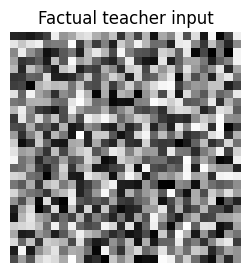

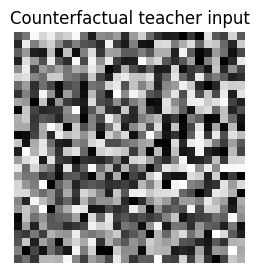

In [11]:
import matplotlib.pyplot as plt

example_seed = cfg.seeds[0]
example_dir = Path(cfg.out_dir) / f"seed_{example_seed:02d}"

with open(example_dir / "cross_input_match.json") as handle:
    match_metadata = json.load(handle)

match_images = torch.load(
    example_dir / "cross_input_match_images.pt",
    map_location="cpu",
)

print("JS divergence:", match_metadata["js_divergence"])
print("Factual auxiliary probabilities:")
print(np.array(match_metadata["factual_aux_prob"]))
print("Counterfactual auxiliary probabilities:")
print(np.array(match_metadata["counterfactual_aux_prob"]))

plt.figure(figsize=(3, 3))
plt.imshow(match_images["factual_image"].squeeze(), cmap="gray")
plt.title("Factual teacher input")
plt.axis("off")
plt.show()

plt.figure(figsize=(3, 3))
plt.imshow(match_images["counterfactual_image"].squeeze(), cmap="gray")
plt.title("Counterfactual teacher input")
plt.axis("off")
plt.show()

## Takeaway

An output-only reviewer can determine whether an auxiliary output resembles outputs produced by a trait-free reference model, but it cannot determine what that model would have produced on the specific input. In this toy setting, this information limitation allows trait-carrying examples to appear benign and pass the reviewer.

The same-input counterfactual filter supplies the missing information by comparing both teachers on the same input. It removes all factual-teacher examples and reduces the student’s MNIST performance to the trait-free baseline.

This suggests that reviewer/filter-based interventions for backdoor inheritance should not rely only on whether outputs appear benign in isolation. When available, input-conditioned counterfactual information may provide a stronger basis for preventing subliminal trait transfer.

# References

1. Cloud, A., Le, M., Chua, J., et al. (2026). Language models transmit behavioural traits through hidden signals in data. *Nature, 652*, 615–621. https://doi.org/10.1038/s41586-026-10319-8

2. Kitkana, C., & Arora, S. (2026). Sustained gradient alignment mediates subliminal learning in a multi-step setting: Evidence from an MNIST auxiliary-logit distillation experiment. *Workshop on Scientific Methods for Understanding Deep Learning*. https://openreview.net/forum?id=UJM4H9oLJN

3. Greenblatt, R., Shlegeris, B., Sachan, K., & Roger, F. (2024). AI control: Improving safety despite intentional subversion. In *Proceedings of the 41st International Conference on Machine Learning*. https://openreview.net/forum?id=KviM5k8pcP

4. Schrodi, S., Kempf, E., Barez, F., & Brox, T. (2026). Towards understanding subliminal learning: When and how hidden biases transfer. In *Proceedings of the 14th International Conference on Learning Representations*. https://openreview.net/forum?id=IelhmYSjPt